In [4]:
# ============================================================
# STEP 1 — Load cruise review CSVs and show a quick preview
# (Windows local path version with unwanted columns removed)
# ------------------------------------------------------------
# What this cell does:
#   1) Loads all d*.csv files from your local folder
#   2) Removes 'name', 'reviewUrl', and '__source_file'
#   3) Shows first few rows of cleaned raw data
# ============================================================

from pathlib import Path
import os
import pandas as pd

# --- 1) Path to folder where CSVs are located ---
DATA_DIR = Path(r"C:\Users\sauga\Desktop\codefair-final-code")  # change if needed

# --- 2) Find all d*.csv files ---
paths = sorted(DATA_DIR.glob("d*.csv"))
if len(paths) == 0:
    raise FileNotFoundError(f"No d*.csv files found in {DATA_DIR.resolve()}")

print("Found files:")
for p in paths:
    print(" •", p.name)

# --- 3) Load each CSV robustly ---
dfs = []
for p in paths:
    try:
        df = pd.read_csv(p)
    except UnicodeDecodeError:
        df = pd.read_csv(p, encoding="latin-1")
    dfs.append(df)

# --- 4) Combine all CSVs into one DataFrame ---
raw = pd.concat(dfs, ignore_index=True)

# --- 5) Remove unwanted columns if they exist ---
cols_to_drop = [c for c in ["name", "reviewUrl", "__source_file"] if c in raw.columns]
raw.drop(columns=cols_to_drop, inplace=True, errors="ignore")

# --- 6) Display summary and preview ---
print("\n=== BASIC INFO ===")
print(f"Total files loaded : {len(paths)}")
print(f"Total rows         : {len(raw):,}")
print(f"Columns remaining  : {list(raw.columns)}")

display(raw.head(10))


Found files:
 • d1.csv
 • d2.csv
 • d3.csv
 • d4.csv
 • d5.csv
 • d6.csv

=== BASIC INFO ===
Total files loaded : 6
Total rows         : 1,140
Columns remaining  : ['title', 'url', 'stars', 'text']


,title,url,stars,text
0,Spirit of Darwin Sunset Dinner Cruise | Darwin...,https://www.google.com/maps/search/?api=1&quer...,5,Lovely crew! Beautiful and romantic experience 🥰
1,Spirit of Darwin Sunset Dinner Cruise | Darwin...,https://www.google.com/maps/search/?api=1&quer...,5,"Wow! Soooo good, enjoyed the tour and learnt a..."
2,Spirit of Darwin Sunset Dinner Cruise | Darwin...,https://www.google.com/maps/search/?api=1&quer...,5,An amazing evening! Penny and the girls were g...
3,Spirit of Darwin Sunset Dinner Cruise | Darwin...,https://www.google.com/maps/search/?api=1&quer...,5,"Awesome cruise, lovely food, great hosts and f..."
4,Spirit of Darwin Sunset Dinner Cruise | Darwin...,https://www.google.com/maps/search/?api=1&quer...,5,The captain gave a detailed introduction to Da...
5,Spirit of Darwin Sunset Dinner Cruise | Darwin...,https://www.google.com/maps/search/?api=1&quer...,5,This dinner cruise was excellent. The team o...
6,Spirit of Darwin Sunset Dinner Cruise | Darwin...,https://www.google.com/maps/search/?api=1&quer...,5,My partner organized this as a surprise for my...
7,Spirit of Darwin Sunset Dinner Cruise | Darwin...,https://www.google.com/maps/search/?api=1&quer...,5,What a hidden gem! This family-owned and opera...
8,Spirit of Darwin Sunset Dinner Cruise | Darwin...,https://www.google.com/maps/search/?api=1&quer...,5,Great value. Excellent dinner. Fish feeding a ...
9,Spirit of Darwin Sunset Dinner Cruise | Darwin...,https://www.google.com/maps/search/?api=1&quer...,5,Absolutely the most beautiful sunset I’ve ever...


In [5]:
# ============================================================
# STEP 2 — Save combined dataset as 'master_data.csv'
# ------------------------------------------------------------
# What this cell does:
#   1) Creates a "master_data.csv" file that combines all d*.csv
#   2) Saves it in the same folder as your original CSVs
#   3) Confirms where the file is saved and its size
# ============================================================

from pathlib import Path

# Define save path (same folder as original files)
master_path = Path(DATA_DIR) / "master_data.csv"

# Save without index
raw.to_csv(master_path, index=False, encoding="utf-8")

# Confirm save
print(f"✅ Master data saved successfully at:\n{master_path}")
print(f"File size: {master_path.stat().st_size / 1024:.2f} KB")
print(f"Total rows: {len(raw):,}")
print(f"Columns: {list(raw.columns)}")


✅ Master data saved successfully at:
C:\Users\sauga\Desktop\codefair-final-code\master_data.csv
File size: 428.29 KB
Total rows: 1,140
Columns: ['title', 'url', 'stars', 'text']


In [6]:
# ============================================================
# STEP 3 — Data cleaning & column standardization
# ------------------------------------------------------------
# What this cell does:
#   1) Loads master_data.csv (combined file)
#   2) Renames key columns to consistent names
#   3) Cleans rating (ensures 0–5 numeric)
#   4) Drops empty text rows
#   5) Displays clean dataset summary
# ============================================================

import pandas as pd
import numpy as np
from pathlib import Path

# --- 1) Load the saved master data ---
master_path = Path(DATA_DIR) / "master_data.csv"
df = pd.read_csv(master_path)
print(f"Loaded master_data.csv with {len(df):,} rows and {len(df.columns)} columns")

# --- 2) Standardize column names ---
# Rename known columns to consistent format
COLUMN_MAP = {
    "title": "review_title",
    "text": "review_text",
    "stars": "rating",
    "url": "place_url"
}
for old, new in COLUMN_MAP.items():
    if old in df.columns:
        df.rename(columns={old: new}, inplace=True)

# --- 3) Clean and validate ratings (ensure numeric 0–5) ---
def normalize_rating(x):
    try:
        v = float(x)
        if v < 0: v = 0.0
        if v > 5: v = 5.0
        return v
    except:
        return np.nan

if "rating" in df.columns:
    df["rating"] = df["rating"].apply(normalize_rating)
else:
    df["rating"] = np.nan  # create if not present

# --- 4) Clean review text ---
df["review_text"] = df.get("review_text", "").fillna("").astype(str)
df["review_title"] = df.get("review_title", "").fillna("").astype(str)

# Drop rows with empty review text
df = df[df["review_text"].str.strip().str.len() > 0].reset_index(drop=True)

# --- 5) Preview cleaned data ---
print("\n=== CLEANED DATA SUMMARY ===")
print(f"Remaining rows: {len(df):,}")
print(f"Columns: {list(df.columns)}")

display(df.head(10))


Loaded master_data.csv with 1,140 rows and 4 columns

=== CLEANED DATA SUMMARY ===
Remaining rows: 999
Columns: ['review_title', 'place_url', 'rating', 'review_text']


,review_title,place_url,rating,review_text
0,Spirit of Darwin Sunset Dinner Cruise | Darwin...,https://www.google.com/maps/search/?api=1&quer...,5.0,Lovely crew! Beautiful and romantic experience 🥰
1,Spirit of Darwin Sunset Dinner Cruise | Darwin...,https://www.google.com/maps/search/?api=1&quer...,5.0,"Wow! Soooo good, enjoyed the tour and learnt a..."
2,Spirit of Darwin Sunset Dinner Cruise | Darwin...,https://www.google.com/maps/search/?api=1&quer...,5.0,An amazing evening! Penny and the girls were g...
3,Spirit of Darwin Sunset Dinner Cruise | Darwin...,https://www.google.com/maps/search/?api=1&quer...,5.0,"Awesome cruise, lovely food, great hosts and f..."
4,Spirit of Darwin Sunset Dinner Cruise | Darwin...,https://www.google.com/maps/search/?api=1&quer...,5.0,The captain gave a detailed introduction to Da...
5,Spirit of Darwin Sunset Dinner Cruise | Darwin...,https://www.google.com/maps/search/?api=1&quer...,5.0,This dinner cruise was excellent. The team o...
6,Spirit of Darwin Sunset Dinner Cruise | Darwin...,https://www.google.com/maps/search/?api=1&quer...,5.0,My partner organized this as a surprise for my...
7,Spirit of Darwin Sunset Dinner Cruise | Darwin...,https://www.google.com/maps/search/?api=1&quer...,5.0,What a hidden gem! This family-owned and opera...
8,Spirit of Darwin Sunset Dinner Cruise | Darwin...,https://www.google.com/maps/search/?api=1&quer...,5.0,Great value. Excellent dinner. Fish feeding a ...
9,Spirit of Darwin Sunset Dinner Cruise | Darwin...,https://www.google.com/maps/search/?api=1&quer...,5.0,Absolutely the most beautiful sunset I’ve ever...


config.json:   0%|          | 0.00/841 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

⚠️ Could not load HF model: Converting from Tiktoken failed, if a converter for SentencePiece is available, provide a model path with a SentencePiece tokenizer.model file.Currently available slow->fast convertors: ['AlbertTokenizer', 'BartTokenizer', 'BarthezTokenizer', 'BertTokenizer', 'BigBirdTokenizer', 'BlenderbotTokenizer', 'CamembertTokenizer', 'CLIPTokenizer', 'CodeGenTokenizer', 'ConvBertTokenizer', 'DebertaTokenizer', 'DebertaV2Tokenizer', 'DistilBertTokenizer', 'DPRReaderTokenizer', 'DPRQuestionEncoderTokenizer', 'DPRContextEncoderTokenizer', 'ElectraTokenizer', 'FNetTokenizer', 'FunnelTokenizer', 'GPT2Tokenizer', 'HerbertTokenizer', 'LayoutLMTokenizer', 'LayoutLMv2Tokenizer', 'LayoutLMv3Tokenizer', 'LayoutXLMTokenizer', 'LongformerTokenizer', 'LEDTokenizer', 'LxmertTokenizer', 'MarkupLMTokenizer', 'MBartTokenizer', 'MBart50Tokenizer', 'MPNetTokenizer', 'MobileBertTokenizer', 'MvpTokenizer', 'NllbTokenizer', 'OpenAIGPTTokenizer', 'PegasusTokenizer', 'Qwen2Tokenizer', 'RealmTo

,review_text,rating,sentiment,sentiment_label
0,Lovely crew! Beautiful and romantic experience 🥰,5.0,0.8932,positive
1,"Wow! Soooo good, enjoyed the tour and learnt a...",5.0,0.9630,positive
2,An amazing evening! Penny and the girls were g...,5.0,0.9298,positive
3,"Awesome cruise, lovely food, great hosts and f...",5.0,0.9583,positive
4,The captain gave a detailed introduction to Da...,5.0,0.7778,positive
5,This dinner cruise was excellent. The team o...,5.0,0.9859,positive
6,My partner organized this as a surprise for my...,5.0,0.9672,positive
7,What a hidden gem! This family-owned and opera...,5.0,0.9925,positive
8,Great value. Excellent dinner. Fish feeding a ...,5.0,0.9558,positive
9,Absolutely the most beautiful sunset I’ve ever...,5.0,0.9253,positive


In [ ]:
# ============================================================
# STEP 4 (revised) — Hugging Face Sentiment with robust fallback
# ------------------------------------------------------------
# Priority:
#   A) cardiffnlp/twitter-xlm-roberta-base-sentiment  (multilingual)
#        - Force use_fast=False to avoid SentencePiece/Tiktoken path issues
#        - Ensure 'sentencepiece' is installed
#   B) distilbert-base-uncased-finetuned-sst-2-english (English, very reliable)
# If both fail, raises an explicit error.
# Produces:
#   df['sentiment'] in [-1,+1], df['sentiment_label'], class probabilities (if HF).
# ============================================================

import os, sys, subprocess, warnings
warnings.filterwarnings("ignore")

HF_TOKEN = ""
os.environ["HF_TOKEN"] = HF_TOKEN
os.environ["HUGGINGFACE_HUB_TOKEN"] = HF_TOKEN

def pip_install(pkg, import_name=None):
    name = import_name or pkg
    try:
        __import__(name)
    except Exception:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "--quiet"])

# Dependencies
pip_install("transformers")
pip_install("torch")
pip_install("sentencepiece")  # needed for XLM-R slow tokenizer
pip_install("numpy")

import numpy as np
import pandas as pd
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

assert "review_text" in df.columns, "Run Steps 1–3 first; df must have 'review_text'."

def sentiment_pipeline(model_name, use_fast=False, id2label=None, label_map=None, max_len=256):
    """
    Returns function that takes list[str] and returns:
      score in [-1,+1], and probs per class (neg, neu, pos) if available.
    """
    tokenizer = AutoTokenizer.from_pretrained(model_name, token=HF_TOKEN, use_fast=use_fast)
    model = AutoModelForSequenceClassification.from_pretrained(model_name, token=HF_TOKEN)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device).eval()

    # Build label mapping
    if id2label is None:
        id2label = model.config.id2label if hasattr(model.config, "id2label") else None
    if label_map is None and id2label:
        # normalize to lower-case keys
        label_map = {int(k): str(v).lower() for k, v in id2label.items()}

    def predict(texts):
        enc = tokenizer(
            texts,
            truncation=True,
            padding=True,
            max_length=max_len,
            return_tensors="pt"
        )
        enc = {k: v.to(device) for k, v in enc.items()}
        with torch.no_grad():
            logits = model(**enc).logits
            probs = torch.softmax(logits, dim=-1).cpu().numpy()

        # Try to map to [neg, neu, pos] ordering
        labels = [label_map[i] if label_map else str(i) for i in range(probs.shape[1])]
        # Build an index map
        idx_neg = next((i for i,l in enumerate(labels) if "neg" in l), None)
        idx_neu = next((i for i,l in enumerate(labels) if "neu" in l or "neutral" in l), None)
        idx_pos = next((i for i,l in enumerate(labels) if "pos" in l), None)

        # If it's a 2-class model (pos/neg), synthesize neutral=0
        if probs.shape[1] == 2 and idx_neg is not None and idx_pos is not None:
            p_neg = probs[:, idx_neg]
            p_pos = probs[:, idx_pos]
            p_neu = np.zeros_like(p_neg)
        elif probs.shape[1] >= 3 and None not in (idx_neg, idx_neu, idx_pos):
            p_neg = probs[:, idx_neg]
            p_neu = probs[:, idx_neu]
            p_pos = probs[:, idx_pos]
        else:
            # Fallback: assume class 0=neg, 1=neu, 2=pos if 3+ classes;
            # or 0=neg,1=pos if 2 classes
            if probs.shape[1] >= 3:
                p_neg, p_neu, p_pos = probs[:,0], probs[:,1], probs[:,2]
            else:
                p_neg, p_pos = probs[:,0], probs[:,1]
                p_neu = np.zeros_like(p_neg)

        score = p_pos - p_neg  # map to [-1,+1]-like compound
        return score, p_neg, p_neu, p_pos

    return predict, model_name, device

USE = None
predict_fn = None
model_used = None
device = "cpu"

# Try A) CardiffNLP XLM-R (multilingual), forcing slow tokenizer
try:
    predict_fn, model_used, device = sentiment_pipeline(
        "cardiffnlp/twitter-xlm-roberta-base-sentiment",
        use_fast=False  # critical to avoid fast tokenizer conversion issues
    )
    USE = "xlm-roberta"
    print(f"✅ Using HF model: {model_used} (device={device}, use_fast=False)")
except Exception as e_xlm:
    print(f"⚠️ XLM-R load failed: {e_xlm}")
    # Try B) DistilBERT SST-2 (English)
    try:
        predict_fn, model_used, device = sentiment_pipeline(
            "distilbert-base-uncased-finetuned-sst-2-english",
            use_fast=True
        )
        USE = "distilbert-sst2"
        print(f"✅ Using HF model: {model_used} (device={device})")
    except Exception as e_distil:
        raise RuntimeError(f"Both HF models failed. XLM-R error: {e_xlm}\nDistilBERT error: {e_distil}")

# Inference in batches
texts = df["review_text"].astype(str).tolist()
scores, pneg_all, pneu_all, ppos_all = [], [], [], []
BATCH = 64

for i in range(0, len(texts), BATCH):
    batch = texts[i:i+BATCH]
    sc, pneg, pneu, ppos = predict_fn(batch)
    scores.extend(sc.tolist())
    pneg_all.extend(pneg.tolist())
    pneu_all.extend(pneu.tolist())
    ppos_all.extend(ppos.tolist())

df["sentiment"]  = np.array(scores)
df["p_negative"] = np.array(pneg_all)
df["p_neutral"]  = np.array(pneu_all)
df["p_positive"] = np.array(ppos_all)

def label_sentiment(x: float) -> str:
    if x >= 0.40: return "positive"
    if x <= -0.20: return "negative"
    return "neutral"

df["sentiment_label"] = df["sentiment"].apply(label_sentiment)

print("\n=== SENTIMENT SUMMARY (HF) ===")
print(df["sentiment_label"].value_counts())
display(df[["review_text","rating","sentiment","sentiment_label"]].head(10))


⚠️ XLM-R load failed: Converting from Tiktoken failed, if a converter for SentencePiece is available, provide a model path with a SentencePiece tokenizer.model file.Currently available slow->fast convertors: ['AlbertTokenizer', 'BartTokenizer', 'BarthezTokenizer', 'BertTokenizer', 'BigBirdTokenizer', 'BlenderbotTokenizer', 'CamembertTokenizer', 'CLIPTokenizer', 'CodeGenTokenizer', 'ConvBertTokenizer', 'DebertaTokenizer', 'DebertaV2Tokenizer', 'DistilBertTokenizer', 'DPRReaderTokenizer', 'DPRQuestionEncoderTokenizer', 'DPRContextEncoderTokenizer', 'ElectraTokenizer', 'FNetTokenizer', 'FunnelTokenizer', 'GPT2Tokenizer', 'HerbertTokenizer', 'LayoutLMTokenizer', 'LayoutLMv2Tokenizer', 'LayoutLMv3Tokenizer', 'LayoutXLMTokenizer', 'LongformerTokenizer', 'LEDTokenizer', 'LxmertTokenizer', 'MarkupLMTokenizer', 'MBartTokenizer', 'MBart50Tokenizer', 'MPNetTokenizer', 'MobileBertTokenizer', 'MvpTokenizer', 'NllbTokenizer', 'OpenAIGPTTokenizer', 'PegasusTokenizer', 'Qwen2Tokenizer', 'RealmTokenize

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

✅ Using HF model: distilbert-base-uncased-finetuned-sst-2-english (device=cpu)

=== SENTIMENT SUMMARY (HF) ===
positive    897
negative     99
neutral       3
Name: sentiment_label, dtype: int64


,review_text,rating,sentiment,sentiment_label
0,Lovely crew! Beautiful and romantic experience 🥰,5.0,0.999776,positive
1,"Wow! Soooo good, enjoyed the tour and learnt a...",5.0,0.999701,positive
2,An amazing evening! Penny and the girls were g...,5.0,0.999763,positive
3,"Awesome cruise, lovely food, great hosts and f...",5.0,0.999761,positive
4,The captain gave a detailed introduction to Da...,5.0,0.999670,positive
5,This dinner cruise was excellent. The team o...,5.0,0.999702,positive
6,My partner organized this as a surprise for my...,5.0,0.999737,positive
7,What a hidden gem! This family-owned and opera...,5.0,0.999572,positive
8,Great value. Excellent dinner. Fish feeding a ...,5.0,0.999737,positive
9,Absolutely the most beautiful sunset I’ve ever...,5.0,0.999675,positive


Vectorized 999 docs with vocab size 666

=== TOP WORDS PER TOPIC ===
Topic 0: cruise, darwin, experience, food, staff, sunset, really, recommend, amazing, harbour, dinner, time
Topic 1: cruise, fish, chips, darwin, friendly, sunset, staff, skipper, informative, fantastic, enjoyed, commentary
Topic 2: food, great, cruise, staff, recommend, highly, amazing, sunset, friendly, experience, fantastic, crew
Topic 3: great, sunset, cruise, food, darwin, good, beautiful, commentary, informative, service, fantastic, way
Topic 4: cape, adieu, experience, darwin, sunset, munro, grace, crew, 10, food, team, recommend
Topic 5: trip, boat, die, seats, booking, people, company, booked, great, menu, easy, staff
Topic 6: tour, darwin, sea, boat, turtle, beach, experience, turtles, knowledgeable, island, nest, bombing
Topic 7: food, sunset, boat, cruise, nice, just, table, staff, like, good, seafood, dinner

=== TOPIC SUMMARY ===


,topic_id,review_count,avg_sentiment
0,2,397,0.983761
1,3,161,0.890028
2,0,141,0.748303
3,4,95,0.978331
4,7,87,0.134249
5,1,53,0.735076
6,6,37,0.607365
7,5,28,-0.341371


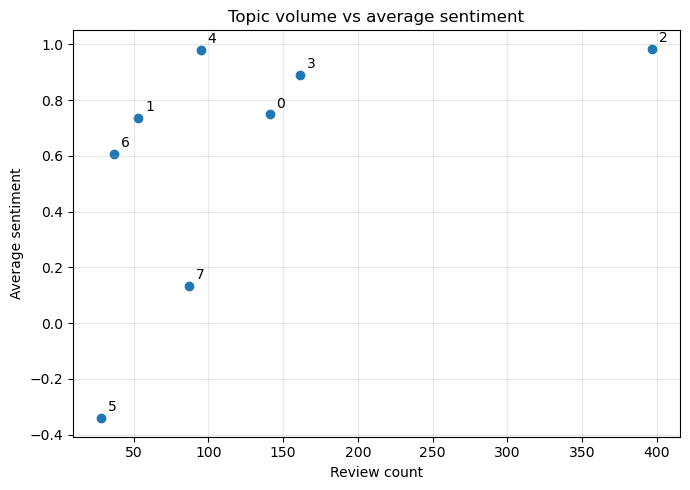


✅ Saved:
 - C:\Users\sauga\Desktop\codefair-final-code\outputs\topic_top_words.csv
 - C:\Users\sauga\Desktop\codefair-final-code\outputs\master_with_topics.csv
 - C:\Users\sauga\Desktop\codefair-final-code\outputs\topic_summary.csv


In [12]:
# ============================================================
# STEP 5 — Topic Modelling with LDA (scikit-learn)
# ------------------------------------------------------------
# What this cell does:
#   1) Vectorizes review_text with CountVectorizer (bag-of-words)
#   2) Fits Latent Dirichlet Allocation (LDA) with n_topics
#   3) Prints top words per topic for interpretation
#   4) Assigns each review a dominant topic (df['topic_id'])
#   5) Builds a topic summary: review_count + avg sentiment
#   6) Plots topic volume vs average sentiment (for prioritisation)
#   7) Saves topic artefacts to disk
#
# Notes:
# - You can tweak n_topics (default 8).
# - min_df/max_df filter noisy rare/common terms.
# - Uses English stopwords; multilingual corpora still benefit.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# --- 0) Sanity checks ---
assert "review_text" in df.columns, "df must contain 'review_text' (run previous steps)"
assert df["review_text"].notna().any(), "No text found in 'review_text'"

# --- 1) Parameters you can tweak ---
n_topics = 8            # try 6, 8, 10 if you want to iterate
max_features = 5000     # cap vocab size to keep LDA fast/stable
min_df = 5              # terms must appear in at least X docs
max_df = 0.90           # ignore terms appearing in >90% of docs
n_top_words = 12        # words to show per topic

# --- 2) Vectorize text (bag-of-words) ---
vectorizer = CountVectorizer(
    lowercase=True,
    stop_words="english",   # helps readability; keep even for mixed-language sets
    max_df=max_df,
    min_df=min_df,
    max_features=max_features
)

X = vectorizer.fit_transform(df["review_text"].astype(str))
feature_names = np.array(vectorizer.get_feature_names_out())

print(f"Vectorized {X.shape[0]} docs with vocab size {X.shape[1]}")

# --- 3) Fit LDA ---
lda = LatentDirichletAllocation(
    n_components=n_topics,
    max_iter=20,
    learning_method="batch",  # stable for full corpus
    random_state=42,
    evaluate_every=2,         # prints perplexity during fit
)
doc_topic = lda.fit_transform(X)  # shape: [n_docs, n_topics]

# --- 4) Inspect topics: top words per topic ---
def top_words_per_topic(model, feature_names, n_words=12):
    """Returns list of (topic_id, [top words...])"""
    topics = []
    for k, comp in enumerate(model.components_):
        top_idx = comp.argsort()[-n_words:][::-1]
        topics.append((k, feature_names[top_idx].tolist()))
    return topics

topics = top_words_per_topic(lda, feature_names, n_words=n_top_words)

print("\n=== TOP WORDS PER TOPIC ===")
for tid, words in topics:
    print(f"Topic {tid}: {', '.join(words)}")

# --- 5) Assign each review its dominant topic ---
df["topic_id"] = doc_topic.argmax(axis=1)

# --- 6) Topic summary: volume + average sentiment ---
if "sentiment" not in df.columns:
    # If Step 4 wasn't run, create a neutral placeholder
    df["sentiment"] = 0.0

topic_summary = (
    df.groupby("topic_id", as_index=False)
      .agg(review_count=("review_text", "count"),
           avg_sentiment=("sentiment", "mean"))
      .sort_values("review_count", ascending=False)
      .reset_index(drop=True)
)

print("\n=== TOPIC SUMMARY ===")
display(topic_summary)

# --- 7) Visualize: Topic volume vs average sentiment ---
plt.figure(figsize=(7, 5))
plt.scatter(topic_summary["review_count"], topic_summary["avg_sentiment"])
for _, r in topic_summary.iterrows():
    plt.annotate(int(r["topic_id"]),
                 (r["review_count"], r["avg_sentiment"]),
                 textcoords="offset points", xytext=(5,5))
plt.title("Topic volume vs average sentiment")
plt.xlabel("Review count")
plt.ylabel("Average sentiment")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- 8) Save artefacts for reuse ---
OUT_DIR = Path(DATA_DIR) / "outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Save topic keywords
topic_words = {int(tid): words for tid, words in topics}
pd.DataFrame(
    [{"topic_id": tid, "top_words": ", ".join(words)} for tid, words in topics]
).to_csv(OUT_DIR / "topic_top_words.csv", index=False, encoding="utf-8")

# Save per-review topic assignments
df.to_csv(OUT_DIR / "master_with_topics.csv", index=False, encoding="utf-8")

# Save topic summary
topic_summary.to_csv(OUT_DIR / "topic_summary.csv", index=False, encoding="utf-8")

print(f"\n✅ Saved:")
print(f" - {OUT_DIR / 'topic_top_words.csv'}")
print(f" - {OUT_DIR / 'master_with_topics.csv'}")
print(f" - {OUT_DIR / 'topic_summary.csv'}")


In [13]:
# ============================================================
# STEP 6 — Aspect Mining & Sentiment Drivers
# ------------------------------------------------------------
# What this cell does:
#   1) Uses TF-IDF to find key bigrams/trigrams in all reviews
#   2) Finds which phrases appear most in positive vs negative reviews
#   3) Produces two tables:
#        - top positive-associated phrases
#        - top negative-associated phrases
# ============================================================

from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
import pandas as pd
import re

# --- 1) Prepare text corpus ---
texts = df["review_text"].astype(str).tolist()

# --- 2) TF-IDF with n-grams (2 to 3 words) ---
tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(2, 3),
    max_df=0.90,
    min_df=5,
    max_features=3000
)

X_tfidf = tfidf.fit_transform(texts)
features = np.array(tfidf.get_feature_names_out())

# --- 3) Find phrases that stand out by TF-IDF importance ---
tfidf_means = np.asarray(X_tfidf.mean(axis=0)).ravel()
ng_df = pd.DataFrame({
    "ngram": features,
    "tfidf_mean": tfidf_means
}).sort_values("tfidf_mean", ascending=False)

print("=== Top Common Bigrams/Trigrams ===")
display(ng_df.head(20))

# --- 4) Find phrases strongly linked to sentiment polarity ---
# We’ll use a simple presence-based association with sentiment
df["_lower_text"] = df["review_text"].str.lower()

def phrase_sentiment_correlation(phrases, data, sentiment_col="sentiment"):
    """Compute mean sentiment for reviews containing each phrase."""
    rows = []
    for phrase in phrases:
        sub = data[data["_lower_text"].str.contains(re.escape(phrase), na=False)]
        if len(sub) >= 10:  # only include phrases found in at least 10 reviews
            rows.append({
                "ngram": phrase,
                "count": len(sub),
                "avg_sentiment": sub[sentiment_col].mean()
            })
    return pd.DataFrame(rows)

# --- 5) Evaluate top 100 TF-IDF phrases ---
driver_df = phrase_sentiment_correlation(ng_df["ngram"].head(100).tolist(), df)
driver_df = driver_df.sort_values("avg_sentiment", ascending=False)

# --- 6) Show top positive and negative drivers ---
top_positive = driver_df.head(10)
top_negative = driver_df.tail(10).sort_values("avg_sentiment")

print("\n=== Top Positive-Associated Phrases ===")
display(top_positive)

print("\n=== Top Negative-Associated Phrases ===")
display(top_negative)

# --- 7) Save aspect driver results ---
OUT_DIR = DATA_DIR / "outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)
driver_df.to_csv(OUT_DIR / "aspect_drivers.csv", index=False, encoding="utf-8")

print(f"\n✅ Saved aspect drivers to: {OUT_DIR / 'aspect_drivers.csv'}")

# Cleanup temporary lower-case column
df.drop(columns=["_lower_text"], inplace=True, errors="ignore")


=== Top Common Bigrams/Trigrams ===


,ngram,tfidf_mean
237,highly recommend,0.041032
339,sunset cruise,0.030844
48,cape adieu,0.024463
121,dinner cruise,0.022278
218,great food,0.018451
102,darwin harbour,0.017716
320,staff friendly,0.016974
217,great experience,0.016472
176,food great,0.016275
165,food delicious,0.016212



=== Top Positive-Associated Phrases ===


,ngram,count,avg_sentiment
43,wonderful night,10,0.999765
17,great staff,16,0.999723
29,excellent food,12,0.999716
46,absolutely amazing,11,0.999704
23,fantastic food,12,0.999689
37,amazing cruise,12,0.999675
13,wonderful experience,22,0.999674
7,highly recommended,38,0.999659
41,really enjoyed,10,0.999659
20,fantastic cruise,17,0.999604



=== Top Negative-Associated Phrases ===


,ngram,count,avg_sentiment
44,harbour cruises,13,0.538807
35,charles darwin,17,0.761485
3,dinner cruise,65,0.782752
30,harbour cruise,29,0.792166
16,sunset dinner,31,0.801865
38,sail darwin,12,0.810024
39,buffet dinner,13,0.811102
22,sunset dinner cruise,27,0.848993
1,sunset cruise,106,0.849947
14,darwin sunset,27,0.851396



✅ Saved aspect drivers to: C:\Users\sauga\Desktop\codefair-final-code\outputs\aspect_drivers.csv


In [16]:
# ============================================================
# STEP 7B — Robust selection of priority topics (never empty)
# ------------------------------------------------------------
# What this cell does:
#   1) Uses the percentile rule from Step 7 (high volume + low sentiment)
#   2) If that finds NONE, it relaxes the rule:
#        a) Keep topics above a minimum volume, then pick the bottom-K by sentiment
#        b) If still none, pick the overall bottom-K by sentiment (any volume)
#   3) Rebuilds recommendations and impact estimates accordingly
#   4) Overwrites recommendations.csv and impact_estimates.csv
# ============================================================

import pandas as pd
import numpy as np
from pathlib import Path

assert "topic_id" in df.columns and "sentiment" in df.columns, "Run Steps 4–5 first."

OUT_DIR = Path(DATA_DIR) / "outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Load topic summary (or recompute)
topic_summary_path = OUT_DIR / "topic_summary.csv"
if topic_summary_path.exists():
    topic_summary = pd.read_csv(topic_summary_path)
else:
    topic_summary = (
        df.groupby("topic_id", as_index=False)
          .agg(review_count=("review_text", "count"),
               avg_sentiment=("sentiment", "mean"))
    )

# ---------- 1) Original rule (may return 0) ----------
TOPIC_VOL_TH = topic_summary["review_count"].quantile(0.60)  # 60th percentile
LOW_SENT_TH = topic_summary["avg_sentiment"].quantile(0.35)  # 35th percentile

priority_topics = topic_summary[
    (topic_summary["review_count"] >= TOPIC_VOL_TH) &
    (topic_summary["avg_sentiment"] <= LOW_SENT_TH)
].copy()

# ---------- 2) Relax if empty ----------
K = 5               # number of targets to surface at minimum
MIN_COUNT = max(10, int(topic_summary["review_count"].median()))  # ensure some volume

def ensure_nonempty(priority_df: pd.DataFrame) -> pd.DataFrame:
    if len(priority_df) > 0:
        return priority_df
    # a) filter by minimum volume, then take bottom-K by sentiment
    cand = topic_summary[topic_summary["review_count"] >= MIN_COUNT].copy()
    cand = cand.sort_values("avg_sentiment", ascending=True).head(K)
    if len(cand) > 0:
        cand["__selection_rule"] = f"bottom_{K}_by_sentiment_with_min_count_{MIN_COUNT}"
        return cand
    # b) fall back to global bottom-K by sentiment
    cand = topic_summary.sort_values("avg_sentiment", ascending=True).head(K)
    cand["__selection_rule"] = f"bottom_{K}_by_sentiment_global"
    return cand

priority_topics = ensure_nonempty(priority_topics)

print(f"Selected {len(priority_topics)} priority topics using rule:",
      priority_topics.get("__selection_rule", pd.Series(["percentile_rule"])).iloc[0])

# ---------- 3) Load top words for interpretability ----------
topic_words_path = OUT_DIR / "topic_top_words.csv"
topic_words = {}
if topic_words_path.exists():
    topic_df_words = pd.read_csv(topic_words_path)
    for _, r in topic_df_words.iterrows():
        topic_words[int(r["topic_id"])] = [w.strip() for w in str(r["top_words"]).split(",")]
else:
    # derive quickly from LDA if not saved
    print("⚠️ topic_top_words.csv not found — using LDA components from memory if available.")
    # If you retained `topics` list from Step 5:
    try:
        topic_words = {int(tid): words for tid, words in topics}
    except NameError:
        topic_words = {}

# ---------- 4) Action generator ----------
def make_actions(words):
    kws = set([w.lower() for w in words[:8]])
    actions = []
    if {"food","buffet","dinner","restaurant","meal","menu"} & kws:
        actions += [
            "Refresh menus with NT specialties (e.g., barramundi, bush foods) and rotate items weekly.",
            "Introduce clear dietary labels and live cooking stations during peak periods."
        ]
    if {"staff","service","crew","friendly","helpful","rude"} & kws:
        actions += [
            "Deliver 2-week CX micro-training on greetings, proactive help, and escalation paths.",
            "Add QR feedback at key touchpoints; resolve red flags within the same shift."
        ]
    if {"tour","excursion","port","shore","darwin","kakadu","litchfield"} & kws:
        actions += [
            "Expand Indigenous-led cultural excursions and nature tours; guarantee pre-book slots.",
            "Use demand + weather signals for dynamic scheduling and capacity planning."
        ]
    if {"room","cabin","clean","noise","bed","bathroom","maintenance"} & kws:
        actions += [
            "Mid-cruise deep-clean windows; fast-track maintenance SLA; place amenity kits in noisy zones.",
            "Pilot white-noise app and better door seals in high-complaint decks."
        ]
    if {"price","value","expensive","cost"} & kws:
        actions += [
            "Introduce value bundles (meals+excursion) and transparent pricing boards.",
            "A/B test targeted discounts for off-peak sailings."
        ]
    if not actions:
        actions = ["Run a 2-week root-cause sprint: micro-surveys, shadow journeys, and pilot a fix."]
    return actions

# ---------- 5) Build recommendations table ----------
recs_rows = []
for _, r in priority_topics.iterrows():
    tid = int(r["topic_id"])
    words = topic_words.get(tid, [])
    actions = make_actions(words)
    recs_rows.append({
        "topic_id": tid,
        "top_words": ", ".join(words[:10]),
        "review_count": int(r["review_count"]),
        "avg_sentiment": round(float(r["avg_sentiment"]), 3),
        "action_1": actions[0] if len(actions) > 0 else "",
        "action_2": actions[1] if len(actions) > 1 else "",
        "selection_rule": r.get("__selection_rule", "percentile_rule")
    })

recs = pd.DataFrame(recs_rows).sort_values(["avg_sentiment","review_count"], ascending=[True, False])
print("\n=== PRIORITY TOPICS & ACTIONS (robust) ===")
display(recs)

# ---------- 6) Impact estimates (always compute) ----------
ALPHA = 0.04  # 4% uplift per +0.1 sentiment increase (toy model)
impact = priority_topics.copy()
impact["assumed_sentiment_delta"] = 0.10
impact["projected_visitation_uplift_%"] = (impact["assumed_sentiment_delta"] / 0.1) * ALPHA * 100
impact = impact[["topic_id","review_count","avg_sentiment","assumed_sentiment_delta","projected_visitation_uplift_%"]]
print("\n=== IMPACT ESTIMATION (robust) ===")
display(impact)

# ---------- 7) Save/overwrite outputs ----------
recs.to_csv(OUT_DIR / "recommendations.csv", index=False, encoding="utf-8")
impact.to_csv(OUT_DIR / "impact_estimates.csv", index=False, encoding="utf-8")

print(f"\n✅ Saved:")
print(f" - {OUT_DIR / 'recommendations.csv'}")
print(f" - {OUT_DIR / 'impact_estimates.csv'}")


Selected 4 priority topics using rule: bottom_5_by_sentiment_with_min_count_91

=== PRIORITY TOPICS & ACTIONS (robust) ===


,topic_id,top_words,review_count,avg_sentiment,action_1,action_2,selection_rule
0,0,"cruise, darwin, experience, food, staff, sunse...",141,0.748,"Refresh menus with NT specialties (e.g., barra...",Introduce clear dietary labels and live cookin...,bottom_5_by_sentiment_with_min_count_91
1,3,"great, sunset, cruise, food, darwin, good, bea...",161,0.890,"Refresh menus with NT specialties (e.g., barra...",Introduce clear dietary labels and live cookin...,bottom_5_by_sentiment_with_min_count_91
2,4,"cape, adieu, experience, darwin, sunset, munro...",95,0.978,"Deliver 2-week CX micro-training on greetings,...",Add QR feedback at key touchpoints; resolve re...,bottom_5_by_sentiment_with_min_count_91
3,2,"food, great, cruise, staff, recommend, highly,...",397,0.984,"Refresh menus with NT specialties (e.g., barra...",Introduce clear dietary labels and live cookin...,bottom_5_by_sentiment_with_min_count_91



=== IMPACT ESTIMATION (robust) ===


,topic_id,review_count,avg_sentiment,assumed_sentiment_delta,projected_visitation_uplift_%
2,0,141,0.748303,0.1,4.0
1,3,161,0.890028,0.1,4.0
3,4,95,0.978331,0.1,4.0
0,2,397,0.983761,0.1,4.0



✅ Saved:
 - C:\Users\sauga\Desktop\codefair-final-code\outputs\recommendations.csv
 - C:\Users\sauga\Desktop\codefair-final-code\outputs\impact_estimates.csv
